<a href="https://colab.research.google.com/github/sahibbedi/btcbasisdashboard-sahibbbedi/blob/main/BTCBasisDashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance -q

Fetching data from Yahoo Finance...


/tmp/ipykernel_2330/3822973843.py:28: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(["BTC-USD", "BTC=F"], period="90d", interval="1d", progress=False)['Close'].dropna()



 📈 BTC BASIS DASHBOARD (Colab Edition)
Spot Price:         $74,471.99
CME Front-Month:    $74,390.00 (Expires May 29)
Live Ann. Basis:    -40.19%
90-Day Context:     Bottom Quartile (Compressing)
------------------------------------------------------------
Summary: Basis is -40.19% annualised, 4407 bps below its 30-day avg, compressing.



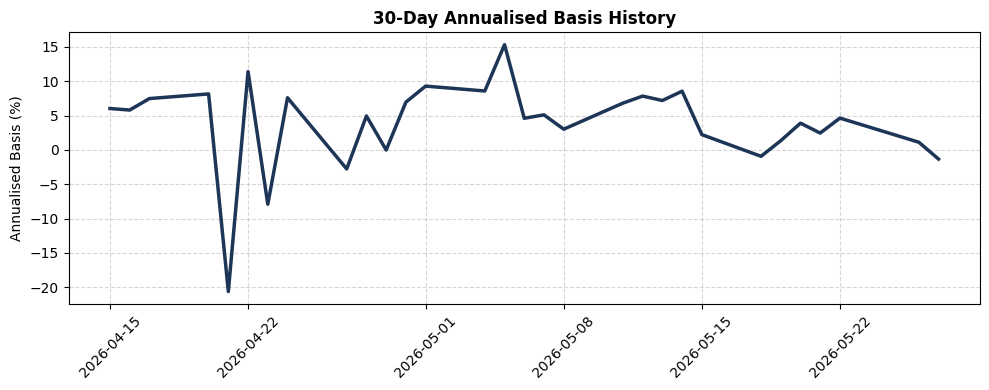


 🧮 TRADE ESTIMATOR
Notional Position:  $100,000.00
Borrow Rate:        5.0%
Net Ann. Yield:     -45.19%
------------------------------------------------------------
Est PnL at Expiry:  $-123.80 (in 1 days)
Est PnL Annualised: $-45,185.78 (if held for 1 year)


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import calendar

# --- Helper: Calculate Next CME Expiry ---
def get_next_expiry():
    today = datetime.now()
    last_day = calendar.monthrange(today.year, today.month)[1]
    last_date = datetime(today.year, today.month, last_day)
    offset = (last_date.weekday() - 4) % 7
    last_friday = last_date - timedelta(days=offset)

    if today > last_friday:
        next_month = today.month + 1 if today.month < 12 else 1
        next_year = today.year if today.month < 12 else today.year + 1
        last_day = calendar.monthrange(next_year, next_month)[1]
        last_date = datetime(next_year, next_month, last_day)
        offset = (last_date.weekday() - 4) % 7
        last_friday = last_date - timedelta(days=offset)

    return last_friday

# --- Fetch Data ---
print("Fetching data from Yahoo Finance...")
df = yf.download(["BTC-USD", "BTC=F"], period="90d", interval="1d", progress=False)['Close'].dropna()

# --- Calculations ---
expiry_date = get_next_expiry()
days_to_expiry = max((expiry_date - datetime.now()).days, 1)

spot = df['BTC-USD']
futures = df['BTC=F']

df['Raw_Basis'] = (futures / spot) - 1
df['Ann_Basis_Pct'] = df['Raw_Basis'] * (365 / 30) * 100

current_spot = spot.iloc[-1]
current_futures = futures.iloc[-1]
current_raw_basis = (current_futures / current_spot) - 1
current_ann_basis = current_raw_basis * (365 / days_to_expiry) * 100

basis_30d = df['Ann_Basis_Pct'].tail(30)
basis_90d = df['Ann_Basis_Pct'].tail(90)

avg_30d = basis_30d.mean()
q25 = np.percentile(basis_90d, 25)
q75 = np.percentile(basis_90d, 75)

if current_ann_basis > q75:
    quartile_status = "Top Quartile (Expanding)"
elif current_ann_basis < q25:
    quartile_status = "Bottom Quartile (Compressing)"
else:
    quartile_status = "Middle 50% (Neutral)"

diff_bps = (current_ann_basis - avg_30d) * 100
trend = "expanding" if diff_bps > 0 else "compressing"

# --- Print Dashboard Metrics ---
print("\n" + "="*60)
print(" 📈 BTC BASIS DASHBOARD (Colab Edition)")
print("="*60)
print(f"Spot Price:         ${current_spot:,.2f}")
print(f"CME Front-Month:    ${current_futures:,.2f} (Expires {expiry_date.strftime('%b %d')})")
print(f"Live Ann. Basis:    {current_ann_basis:.2f}%")
print(f"90-Day Context:     {quartile_status}")
print("-" * 60)
print(f"Summary: Basis is {current_ann_basis:.2f}% annualised, {abs(diff_bps):.0f} bps {'above' if diff_bps > 0 else 'below'} its 30-day avg, {trend}.")
print("="*60 + "\n")

# --- Plot Chart ---
plt.figure(figsize=(10, 4))
plt.plot(basis_30d.index, basis_30d.values, color='#1D3557', linewidth=2.5)
plt.title("30-Day Annualised Basis History", fontweight='bold')
plt.ylabel("Annualised Basis (%)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Trade Estimator ---
# 💡 CHANGE THESE VARIABLES TO TEST DIFFERENT SCENARIOS
NOTIONAL = 100000  # $100,000 position
BORROW_RATE = 5.0  # 5.0% annual financing rate

net_ann_yield = current_ann_basis - BORROW_RATE
est_pnl_annual = NOTIONAL * (net_ann_yield / 100)
est_pnl_expiry = est_pnl_annual * (days_to_expiry / 365)

print("\n" + "="*60)
print(" 🧮 TRADE ESTIMATOR")
print("="*60)
print(f"Notional Position:  ${NOTIONAL:,.2f}")
print(f"Borrow Rate:        {BORROW_RATE}%")
print(f"Net Ann. Yield:     {net_ann_yield:.2f}%")
print("-" * 60)
print(f"Est PnL at Expiry:  ${est_pnl_expiry:,.2f} (in {days_to_expiry} days)")
print(f"Est PnL Annualised: ${est_pnl_annual:,.2f} (if held for 1 year)")
print("="*60)